# Strategy 27 — safer fast mean reversion, on fake futures

Full workflow of Carver's Strategy 27 ([book notes](../../docs/research/books/robcarver/strategy_27.md)),
built on Strategy 26 ([fast mean reversion](../../docs/research/books/robcarver/strategy_26.md)),
Strategy 13 ([vol multiplier](../../docs/research/books/robcarver/strategy_13.md)) and
Strategy 3 ([blended vol](../../docs/research/books/robcarver/strategy_03.md)).

`fake hourly prices → daily inputs (equilibrium, σ, trend, vol multiplier) → forecast → position`
`→ limit-order ladder per hour → P&L, costs → S26 vs S27`

**All prices are fabricated.** The generator puts a fast mean-reverting wiggle, slow trends and
volatility regimes into the prices, so the strategy has something to find. The P&L below
illustrates the mechanics; it is not evidence about real markets.

In [1]:
import os
from pathlib import Path

ROOT = next(p.resolve() for p in [Path.cwd(), *Path.cwd().parents] if (p / 'py' / 'apollo3').exists())
for variable, folder in [('XDG_CACHE_HOME', 'xdg-cache'), ('MPLCONFIGDIR', 'mplconfig')]:
    os.environ.setdefault(variable, str(ROOT / 'tmp' / folder))
    Path(os.environ[variable]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 27
YEARS, DAYS_PER_YEAR, BARS_PER_DAY = 12, 256, 8   # Carver uses 256 business days a year
CAPITAL, TAU = 1_000_000, 0.20                     # Carver's standard 20% risk target
IDM = 1.56                                         # Carver's IDM table, 4 instruments
WEIGHT = 1 / 4                                     # equal instrument weights
COMMISSION = 1.0                                   # fake $ per contract, every fill
WARMUP_DAYS = DAYS_PER_YEAR                        # one year of history before trading

# Fake contract specs. Multipliers chosen so the average position is tens of contracts.
SPECS = pd.DataFrame({
    'price0':     [4500.0, 110.0, 1.10, 80.0],
    'multiplier': [5, 1000, 62_500, 100],
    'vol':        [0.16, 0.06, 0.08, 0.30],     # long-run annualised vol of the fake series
    'tick':       [0.25, 1 / 64, 0.00005, 0.01],
}, index=['EQ', 'BOND', 'FX', 'CMDTY'])
display(SPECS)

,price0,multiplier,vol,tick
EQ,4500.0,5,0.16,0.250000
BOND,110.0,1000,0.06,0.015625
FX,1.1,62500,0.08,0.000050
CMDTY,80.0,100,0.30,0.010000


## 1. Fake hourly futures prices

One continuous (already back-adjusted) series per instrument, so there are no rolls.
Log price per hourly bar = slow trending drift + random walk with regime-switching vol
+ an Ornstein-Uhlenbeck wiggle with a one-day half-life (the thing fast mean reversion harvests).
The OU size is fixed while random-walk vol switches regimes, so in high-vol regimes the
mean-reverting part is a smaller share of the moves — Carver's "wrong kind of volatility".

,EQ,BOND,FX,CMDTY
time,,,,
2014-01-01 09:00:00,4514.064816,110.077340,1.100900,80.656132
2014-01-01 10:00:00,4532.578005,110.218578,1.103099,80.344774
2014-01-01 11:00:00,4568.154607,110.139025,1.104436,80.568251
2014-01-01 12:00:00,4584.416498,110.115182,1.103289,80.619905
2014-01-01 13:00:00,4594.373708,109.944976,1.104530,79.873657
2014-01-01 14:00:00,4574.803540,110.011450,1.101889,79.954788
2014-01-01 15:00:00,4588.387376,110.055606,1.104097,80.299375
2014-01-01 16:00:00,4573.743396,109.947168,1.100648,81.379044
2014-01-02 09:00:00,4614.164163,109.841276,1.100179,81.262159


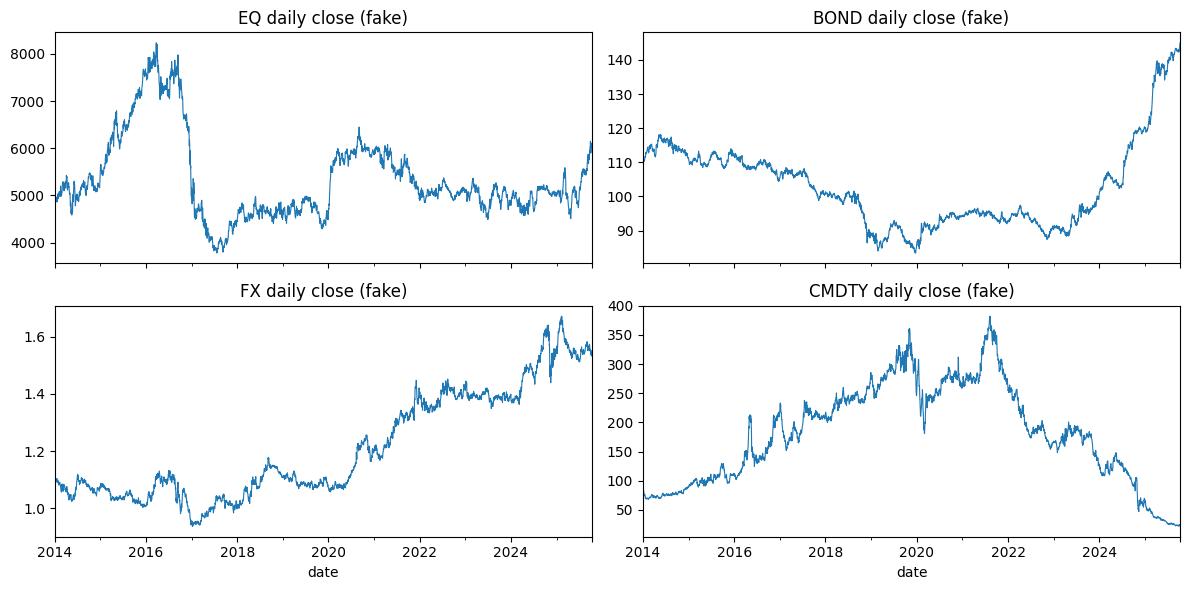

In [2]:
rng = np.random.default_rng(SEED)
DATES = pd.bdate_range('2014-01-01', periods=YEARS * DAYS_PER_YEAR)
HOURS = pd.to_timedelta(np.arange(9, 9 + BARS_PER_DAY), unit='h')
BAR_TIMES = (DATES.values[:, None] + HOURS.values[None, :]).ravel()


def ar1(phi, innovations):
    out = np.zeros_like(innovations)
    for t in range(1, len(out)):
        out[t] = phi * out[t - 1] + innovations[t]
    return out


def fake_hourly_prices(price0, vol):
    n = len(DATES)
    # Daily log-vol regime: persistent AR(1) plus rare upward jumps.
    jumps = (rng.random(n) < 0.004) * rng.uniform(0.5, 1.2, n)
    log_vol = ar1(0.98, 0.07 * rng.standard_normal(n) + jumps)
    daily_vol = vol / 16 * np.exp(log_vol) / np.exp(log_vol).mean()
    # Slow trend: daily drift with stationary size ~0.7 annual Sharpe.
    drift_sd = 0.7 * vol / DAYS_PER_YEAR
    drift = ar1(0.995, drift_sd * np.sqrt(1 - 0.995**2) * rng.standard_normal(n))
    walk = (np.repeat(daily_vol, BARS_PER_DAY) / np.sqrt(BARS_PER_DAY) * rng.standard_normal(n * BARS_PER_DAY)
            + np.repeat(drift, BARS_PER_DAY) / BARS_PER_DAY)
    # Mean-reverting wiggle: OU, half-life one day, stationary sd = 0.4 x normal daily vol.
    phi = 0.5 ** (1 / BARS_PER_DAY)
    ou = ar1(phi, 0.4 * vol / 16 * np.sqrt(1 - phi**2) * rng.standard_normal(n * BARS_PER_DAY))
    return price0 * np.exp(np.cumsum(walk) + ou)


hourly = pd.DataFrame({i: fake_hourly_prices(s.price0, s.vol) for i, s in SPECS.iterrows()},
                      index=pd.DatetimeIndex(BAR_TIMES, name='time'))
close = hourly.groupby(hourly.index.normalize()).last().rename_axis('date')
display(hourly.head(10))

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for ax, name in zip(axes.flat, SPECS.index):
    close[name].plot(ax=ax, title=f'{name} daily close (fake)', lw=0.8)
plt.tight_layout(); plt.show()

## 2. Daily inputs (all known at yesterday's close)

Each value below is computed on daily closes up to day *t−1* and held fixed through
the hourly bars of day *t*.

| input | formula | source |
| :-- | :-- | :-- |
| σ% | 0.3 × 10-year average + 0.7 × EWMA(32) vol of daily % returns, annualised | S3 |
| σ_p | price × σ% / 16 (daily vol in price points) | S7 |
| Equilibrium | EWMA(span 5) of daily closes | S26 |
| Trend | EWMA(16) − EWMA(64) of daily closes; only its sign is used | S27 |
| V | σ% / average σ% over the last 2560 days | S13 |
| Q | quantile of today's V in all of its history so far | S13 |
| M | EWMA(span 10) of 2 − 1.5 Q | S13 |
| A | average position = Capital × IDM × weight × τ / (multiplier × price × σ%) | S7 |

,close,sigma_pct,sigma_p,equilibrium,trend,V,Q,M,avg_position
date,,,,,,,,,
2014-12-25,5196.514,0.135,43.992,5198.034,-14.058,0.695,0.004,1.980,22.163
2014-12-26,5160.226,0.135,43.668,5185.431,-15.998,0.695,0.009,1.981,22.328
2014-12-29,5252.600,0.148,48.516,5207.821,-9.575,0.760,0.053,1.970,20.097
2014-12-30,5323.038,0.151,50.385,5246.226,2.072,0.779,0.110,1.945,19.351
2014-12-31,5468.185,0.172,58.885,5320.213,24.633,0.887,0.329,1.866,16.558


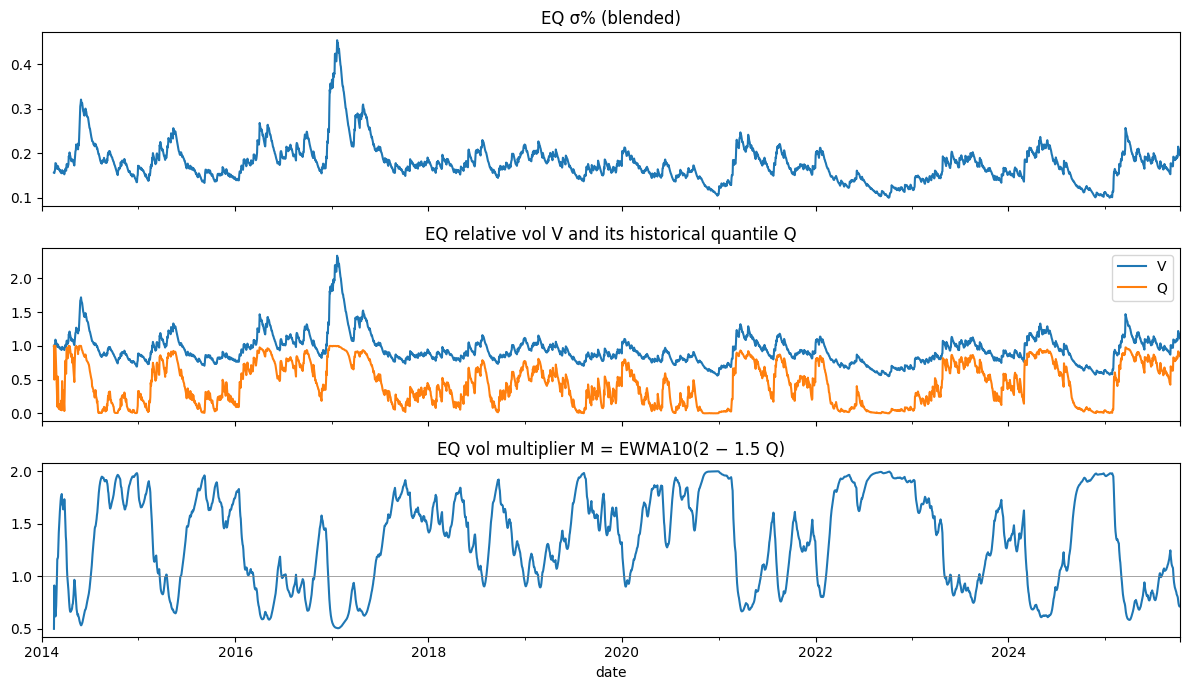

In [3]:
def daily_inputs(close):
    returns = close.pct_change()
    vol_now = returns.ewm(span=32, min_periods=32).std() * 16
    sigma_pct = 0.3 * vol_now.rolling(10 * DAYS_PER_YEAR, min_periods=1).mean() + 0.7 * vol_now
    relative_vol = sigma_pct / sigma_pct.rolling(10 * DAYS_PER_YEAR, min_periods=1).mean()
    quantile = relative_vol.expanding().rank(pct=True)
    inputs = pd.concat({
        'close': close,
        'sigma_pct': sigma_pct,
        'sigma_p': close * sigma_pct / 16,
        'equilibrium': close.ewm(span=5).mean(),
        'trend': close.ewm(span=16).mean() - close.ewm(span=64).mean(),
        'V': relative_vol,
        'Q': quantile,
        'M': (2 - 1.5 * quantile).ewm(span=10).mean(),
        'avg_position': CAPITAL * IDM * WEIGHT * TAU / (SPECS.multiplier * close * sigma_pct),
    }, axis=1)
    return inputs.shift(1)   # row t = what we know before trading day t


inputs = daily_inputs(close)
display(inputs.xs('EQ', axis=1, level=1).iloc[WARMUP_DAYS:WARMUP_DAYS + 5].round(3))

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
eq = inputs.xs('EQ', axis=1, level=1)
eq.sigma_pct.plot(ax=axes[0], title='EQ σ% (blended)')
eq[['V', 'Q']].plot(ax=axes[1], title='EQ relative vol V and its historical quantile Q')
eq.M.plot(ax=axes[2], title='EQ vol multiplier M = EWMA10(2 − 1.5 Q)')
axes[2].axhline(1, color='grey', lw=0.5)
plt.tight_layout(); plt.show()

## 3. Forecast and position

Mean-reversion forecast at any price *p* during day *t*:

$$F = \text{cap}_{\pm 20}\Big(\text{scalar} \times M \times \frac{\text{Equilibrium} - p}{\sigma_p}\Big)$$

- **S26:** scalar 9.3, M = 1, no filter.
- **S27:** scalar 20, M from step 2, and F = 0 whenever sign(F) ≠ sign(trend).

Position (S7 sizing; A already holds capital, IDM, weight, τ, σ%): $N(p) = F(p) \times A / 10$.

Inverting N(p) on its linear part gives the **limit price** at which we want exactly *n* contracts:

$$p_n = \text{Equilibrium} - n \times \frac{10\,\sigma_p}{\text{scalar} \times M \times A}$$

This is the book's formula, with 10 σ_p as the "notional exposure" term.

limit_price inverts target_position on the uncapped, trend-allowed side


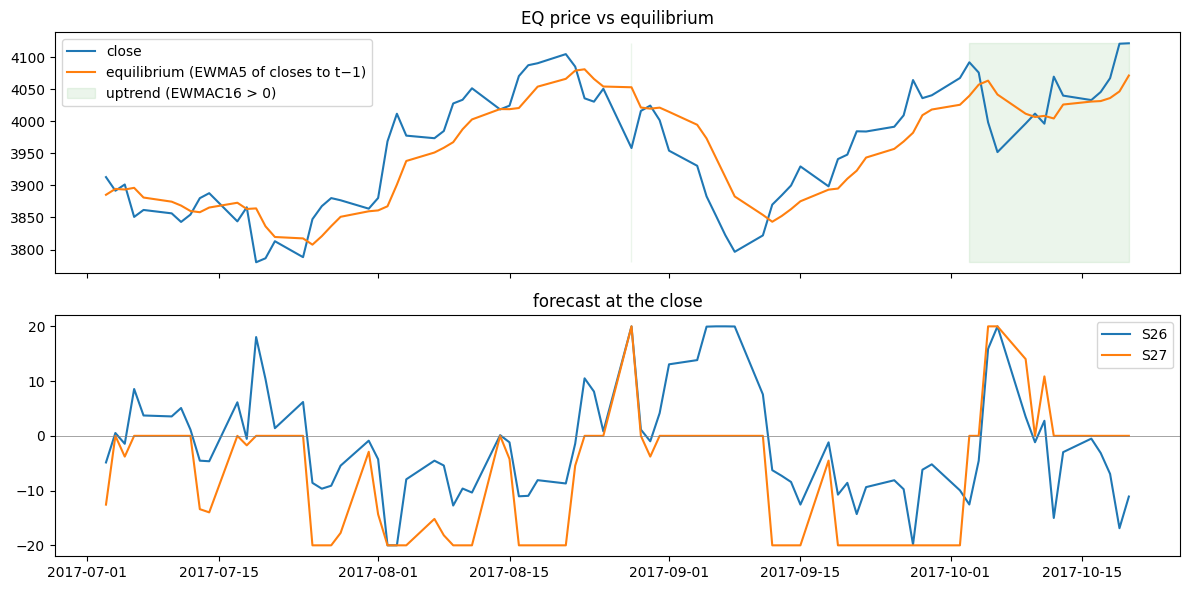

In [4]:
VARIANTS = {
    'S26': dict(scalar=9.3, use_vol_multiplier=False, use_trend_filter=False),
    'S27': dict(scalar=20.0, use_vol_multiplier=True, use_trend_filter=True),
}


def forecast(p, day, scalar, use_vol_multiplier, use_trend_filter):
    m = day.M if use_vol_multiplier else 1.0
    f = np.clip(scalar * m * (day.equilibrium - p) / day.sigma_p, -20, 20)
    if use_trend_filter:
        f = np.where(np.sign(f) == np.sign(day.trend), f, 0.0)
    return f


def target_position(p, day, **variant):
    return forecast(p, day, **variant) * day.avg_position / 10


def limit_price(n, day, scalar, use_vol_multiplier, **_):
    m = day.M if use_vol_multiplier else 1.0
    return day.equilibrium - n * 10 * day.sigma_p / (scalar * m * day.avg_position)


# Check: the limit price for n contracts maps back to exactly n contracts (S27, uptrend day).
day = inputs.xs('EQ', axis=1, level=1).iloc[WARMUP_DAYS:].query('trend > 0').iloc[0]
for n in [1, 3, 5]:
    assert np.isclose(target_position(limit_price(n, day, **VARIANTS['S27']), day, **VARIANTS['S27']), n)
print('limit_price inverts target_position on the uncapped, trend-allowed side')

# Daily-close forecasts for ~four months of EQ around a trend flip: S26 trades both ways,
# S27 only with the trend.
eq = inputs.xs('EQ', axis=1, level=1)
flip = eq.index.get_loc((np.sign(eq.trend).diff().abs() == 2).loc[DATES[WARMUP_DAYS + 500]:].idxmax())
eq = eq.iloc[flip - 40:flip + 40]
eq_close = close.EQ.loc[eq.index]
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(eq_close, label='close')
axes[0].plot(eq.equilibrium, label='equilibrium (EWMA5 of closes to t−1)')
axes[0].fill_between(eq.index, eq_close.min(), eq_close.max(), where=eq.trend > 0,
                     color='green', alpha=0.08, label='uptrend (EWMAC16 > 0)')
axes[0].legend(); axes[0].set_title('EQ price vs equilibrium')
for name, variant in VARIANTS.items():
    axes[1].plot(eq.index, forecast(eq_close, eq, **variant), label=name)
axes[1].axhline(0, color='grey', lw=0.5); axes[1].legend(); axes[1].set_title('forecast at the close')
plt.tight_layout(); plt.show()

## 4. Execution: a limit-order ladder on hourly bars

Holding *N* contracts, we rest a **buy limit at $p_{N+1}$** and a **sell limit at $p_{N-1}$**;
after a fill both move one rung along. No buffering (S26). So *N* only changes once the target
N(p) crosses N ± 1, which is the same as $N \leftarrow \text{clip}(N, \lfloor N(p) \rfloor, \lceil N(p) \rceil)$.

Simulation rules, per instrument and hourly bar:
- **First bar of the day:** inputs changed overnight, so yesterday's orders are cancelled and we
  trade at market, paying half a tick of spread plus commission. This is also how S27 exits when
  the trend flips.
- **Later bars:** rungs crossed during the hour are limit fills: commission only, no spread.
- **Fill price = the hourly print.** Filling each crossed rung at its own limit price would
  assume price moved in a straight line between prints. That misses the back-and-forth inside
  the hour that a resting ladder also trades, and charges about ½ × contracts-per-point ×
  (hourly move)² per bar — a large artificial loss, even on a pure random walk.

In [5]:
OPEN_HOUR = HOURS.min().components.hours


def simulate(name, scalar, use_vol_multiplier, use_trend_filter):
    variant = dict(scalar=scalar, use_vol_multiplier=use_vol_multiplier, use_trend_filter=use_trend_filter)
    spec = SPECS.loc[name]
    price = hourly[name].loc[DATES[WARMUP_DAYS]:]
    day = inputs.xs(name, axis=1, level=1).reindex(price.index.normalize()).set_index(price.index)
    target = target_position(price, day, **variant)
    position, held = np.zeros(len(price)), 0.0
    for b, t in enumerate(target):   # the ladder: hold N until the target crosses N ± 1
        held = min(max(held, np.floor(t)), np.ceil(t))
        position[b] = held
    trades = np.diff(position, prepend=0.0)
    at_open = price.index.hour == OPEN_HOUR
    cost = np.abs(trades) * (COMMISSION + at_open * spec.tick / 2 * spec.multiplier)
    pnl = np.r_[0.0, position[:-1] * np.diff(price.values)] * spec.multiplier - cost
    bars = pd.DataFrame({'price': price, 'target': target, 'position': position, 'trade': trades,
                         'pnl': pnl, 'cost': cost}, index=price.index)
    by_day = bars.groupby(bars.index.normalize())
    daily = pd.DataFrame({
        'pnl': by_day.pnl.sum(), 'cost': by_day.cost.sum(),
        'contracts_traded': by_day.trade.apply(lambda t: t.abs().sum()),
        'position': by_day.position.last(),
    })
    days = inputs.xs(name, axis=1, level=1).loc[daily.index]
    daily['avg_position'] = days.avg_position
    daily['forecast'] = forecast(close[name].loc[daily.index], days, **variant)
    return bars, daily


results = {(v, i): simulate(i, **VARIANTS[v]) for v in VARIANTS for i in SPECS.index}
display(results[('S27', 'EQ')][1].head())

,pnl,cost,contracts_traded,position,avg_position,forecast
time,,,,,,
2014-12-25,692.908362,8.000,8.0,0.0,22.162954,0.0
2014-12-26,-5073.911068,66.000,66.0,-44.0,22.327697,-20.0
2014-12-29,-14249.081607,4.875,3.0,-41.0,20.096659,-20.0
2014-12-30,-6359.804546,66.625,41.0,0.0,19.351071,0.0
2014-12-31,0.000000,0.000,0.0,0.0,16.557728,0.0


### One day of the S27 ladder, close up

An EQ day with limit fills in several hours: each hour's resting buy and sell rungs, and where the
position changed.

2020-01-24  equilibrium 5502.81  σ_p 70.42  trend up  M 0.94  A 13.8


,price,target,position,trade,pnl,cost,buy rung,sell rung
time,,,,,,,,
2020-01-24 09:00:00,5526.90,0.00,0.0,0.0,-0.00,0.0,5500.11,NaN
2020-01-24 10:00:00,5484.84,6.65,6.0,6.0,-6.00,6.0,5483.89,5489.30
2020-01-24 11:00:00,5479.97,8.45,8.0,2.0,-148.30,2.0,5478.49,5483.89
2020-01-24 12:00:00,5496.94,2.17,3.0,-5.0,673.71,5.0,5492.00,5497.40
2020-01-24 13:00:00,5489.30,5.00,4.0,1.0,-115.49,1.0,5489.30,5494.70
2020-01-24 14:00:00,5481.60,7.85,7.0,3.0,-156.97,3.0,5481.19,5486.60
2020-01-24 15:00:00,5484.87,6.64,7.0,0.0,114.43,0.0,5481.19,5486.60
2020-01-24 16:00:00,5487.93,5.51,6.0,-1.0,106.02,1.0,5483.89,5489.30


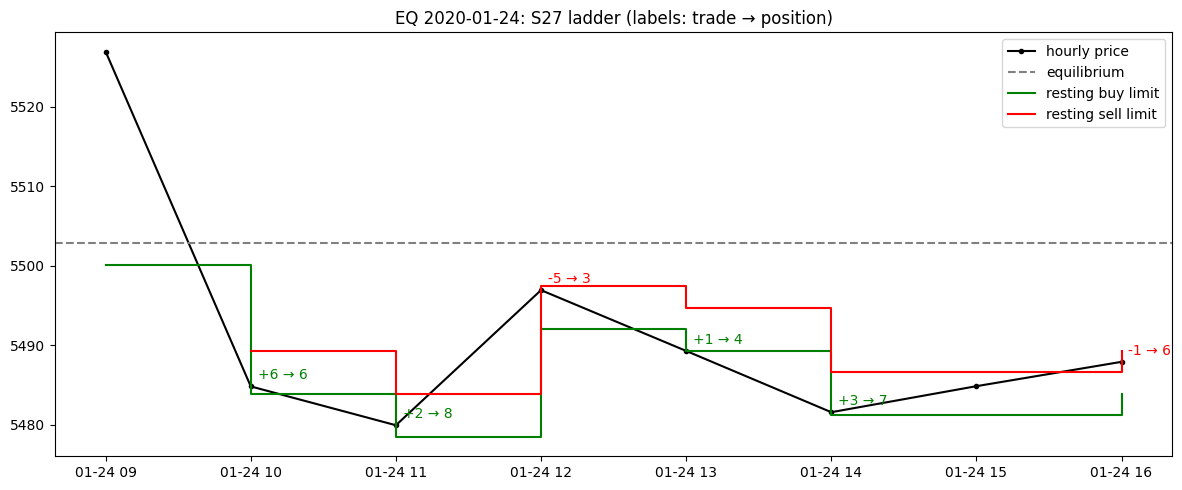

In [6]:
bars27 = results[('S27', 'EQ')][0]
limit_bars = bars27[(bars27.index.hour != OPEN_HOUR) & (bars27.trade != 0)]
hours_with_fills = limit_bars.groupby(limit_bars.index.normalize()).size()
example = hours_with_fills[hours_with_fills >= 3].loc['2020':].index[0]
day = inputs.xs('EQ', axis=1, level=1).loc[example]
ladder = bars27.loc[example:example + pd.Timedelta(hours=23)].copy()
# Rungs only exist inside the reachable range: ±cap, and one side is zero under the trend filter.
lowest, highest = (target_position(p, day, **VARIANTS['S27']) for p in (np.inf, -np.inf))
ladder['buy rung'] = limit_price(ladder.position + 1, day, **VARIANTS['S27']).where(ladder.position + 1 <= highest)
ladder['sell rung'] = limit_price(ladder.position - 1, day, **VARIANTS['S27']).where(ladder.position - 1 >= lowest)
print(f'{example.date()}  equilibrium {day.equilibrium:.2f}  σ_p {day.sigma_p:.2f}  '
      f'trend {"up" if day.trend > 0 else "down"}  M {day.M:.2f}  A {day.avg_position:.1f}')
display(ladder.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ladder.index, ladder.price, 'k.-', label='hourly price')
ax.axhline(day.equilibrium, color='grey', ls='--', label='equilibrium')
ax.step(ladder.index, ladder['buy rung'], where='post', color='green', label='resting buy limit')
ax.step(ladder.index, ladder['sell rung'], where='post', color='red', label='resting sell limit')
for t, row in ladder[ladder.trade != 0].iterrows():
    ax.annotate(f'{row.trade:+.0f} → {row.position:.0f}', (t, row.price), textcoords='offset points',
                xytext=(5, 5), color='green' if row.trade > 0 else 'red')
ax.legend(); ax.set_title(f'EQ {example.date()}: S27 ladder (labels: trade → position)')
plt.tight_layout(); plt.show()

## 5. Results: S26 vs S27

Per instrument and for the 4-instrument portfolio (P&L summed, as a fraction of capital).
Turnover follows Carver: contracts traded per year ÷ (2 × average position).
"Time on" is the share of daily closes with a non-zero forecast.

mean annual return  costs  std dev  Sharpe  skew (monthly)  \
S26 EQ                       0.06  -0.01     0.08    0.75           -1.17   
    BOND                     0.07  -0.01     0.08    0.78            1.00   
    FX                       0.09  -0.01     0.08    1.16           -0.35   
    CMDTY                    0.01  -0.01     0.09    0.12           -1.13   
S27 EQ                       0.02  -0.01     0.08    0.26           -0.14   
    BOND                     0.07  -0.01     0.08    0.87           -1.13   
    FX                       0.05  -0.01     0.08    0.65           -0.44   
    CMDTY                    0.04  -0.01     0.08    0.47           -0.79   
S26 portfolio                0.23  -0.04     0.16    1.39           -0.56   
S27 portfolio                0.18  -0.03     0.16    1.12           -0.03   

               turnover  avg |forecast|  time on  
S26 EQ           239.46            8.76     1.00  
    BOND         239.38            8.91     1.00  
    FX           239.28            8.65     1.00  
    CMDTY        247.74            9.06     1.00  
S27 EQ           191.39            7.10     0.48  
    BOND         181.77            6.30     0.45  
    FX           189.89            6.65     0.47  
    CMDTY        171.81            6.50     0.44  
S26 portfolio       NaN             NaN      NaN  
S27 portfolio       NaN             NaN      NaN

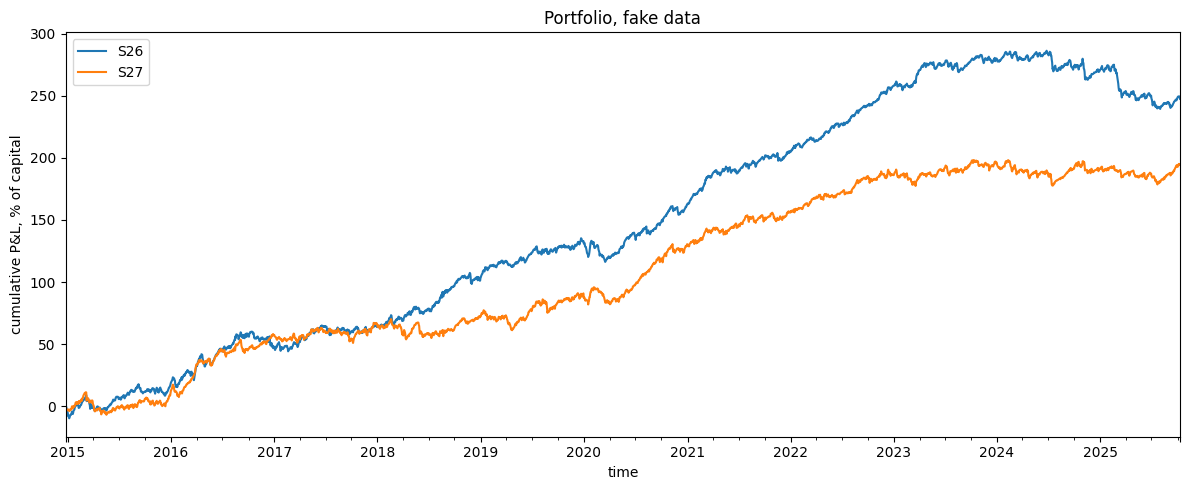

In [7]:
def stats(pnl, cost, daily=None):
    returns = pnl / CAPITAL
    out = {
        'mean annual return': returns.mean() * DAYS_PER_YEAR,
        'costs': -cost.mean() * DAYS_PER_YEAR / CAPITAL,
        'std dev': returns.std() * 16,
        'Sharpe': returns.mean() / returns.std() * 16,
        'skew (monthly)': returns.resample('ME').sum().skew(),
    }
    if daily is not None:
        out['turnover'] = daily.contracts_traded.mean() * DAYS_PER_YEAR / (2 * daily.avg_position.mean())
        out['avg |forecast|'] = daily.forecast.abs().mean()
        out['time on'] = (daily.forecast != 0).mean()
    return out


table = {(v, i): stats(daily.pnl, daily.cost, daily) for (v, i), (_, daily) in results.items()}
portfolio = {v: sum(results[(v, i)][1][['pnl', 'cost']] for i in SPECS.index) for v in VARIANTS}
table.update({(v, 'portfolio'): stats(p.pnl, p.cost) for v, p in portfolio.items()})
display(pd.DataFrame(table).T.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
for v, p in portfolio.items():
    (p.pnl.cumsum() / CAPITAL * 100).plot(ax=ax, label=v)
ax.set_ylabel('cumulative P&L, % of capital'); ax.legend(); ax.set_title('Portfolio, fake data')
plt.tight_layout(); plt.show()

## Reading the results

- The trend filter switches S27 off about half the time ("time on"). That is why Carver doubles the
  scalar to 20. Average |forecast| still lands below his target of 10 for both variants, because his
  scalars were estimated on real prices, not on this generator.
- On this fake data S27 does **not** beat S26 on Sharpe. The fake trends are gentle, so buying a dip
  against the trend is rarely punished, and the filter mostly halves the opportunity. Carver's gain
  comes from real markets, where fading a strong trend means catching a falling knife.
- What does show up here is the protection: portfolio monthly skew moves from clearly negative (S26)
  to about zero (S27).
- The numbers come from one seed of a generator built with a mean-reverting wiggle, trends and vol
  regimes. Change `SEED` or the generator and they change; only the mechanics carry over.
- Skipped from the book: rolls (series are already continuous), FX (everything in USD), rounding limit
  prices to the tick, and estimating forecast scalars (the book's fixed values are used). To run the
  same workflow on real data, replace `hourly` with back-adjusted hourly prices and `SPECS` with real
  contract specs.